# Dev for ophys-mFISH GLM
- Using DataAsset from design matrix capsule
- Test using one session (session_name = 'multiplane-ophys_721291_2024-05-16_08-57-00')
- L2 regularized Gaussian GLM

In [1]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils


In [9]:
# data info
session_name = 'multiplane-ophys_721291_2024-05-16_08-57-00'
data_type = 'filtered_events'
dm_version = 0

# for now dataAssets are manually attached
# in the future, it should include searching and attaching corresponding data assets


# load data
data_path = Path('/root/capsule/data')

dm_path = data_path / f'design_matrix_v{dm_version:02}_{session_name}'
rm_path = data_path / f'response_matrix_{session_name}_{data_type}'

x_fn = dm_path / 'design_matrix.nc'

X = xr.open_dataarray(x_fn)

run_params_fn = dm_path / 'run_params.json'
with open(run_params_fn, 'r') as f:
    run_params = json.load(f)

response_fn = rm_path / 'response_matrix.nc'

response = xr.open_dataarray(response_fn)

assert X.shape[0] == response.shape[0]

response_info_fn = rm_path / 'response_info.npy'
response_info = np.load(response_info_fn, allow_pickle=True).item()
ophys_frame_rate = response_info['ophys_frame_rate']

In [10]:
# Trim frames based on kernel offsets
offsets = [int(w.split('_')[1]) for w in X.weights.values]
min_offset = min(min(offsets), 0)
max_offset = max(max(offsets), 0)
use_indices = range(max_offset, X.shape[0] + min_offset)  # min_offset is negative or 0

X_trim = X[use_indices, :]
response_trim = response[use_indices, :]


In [136]:
# defining fit params
fit_params = {
    'ElasticNet': False,                        # Use ElasticNet (True) or Ridge (False) regression
    'ElasticNet_alpha':0.95,                    #
    'L2_grid_range':[.1, 500],                  # Min/Max L2 values
    'L2_grid_num': 40,                          # Number of L2 values
    'L2_grid_type':'linear',                    # how to space L2 options, must be: 'log' or 'linear'
    'cv_folds': 5,                              # Number of cross-validation folds
    'cv_nested_fold': 5,                        # Number of nested cross-validation folds, for hyperparameter optimization (e.g., L2 lambda)
    'cv_stratify': {                            # Stratify cross-validation folds by these variables (['time', 'image_name', 'running_speed', 'lick_frequency', 'engagement', 'rolling_performance'])
        'variables': ['time'],
        'num_time_stratification': 5,           # Number of stratification for time. The rest are binary (at least for now)
        # 'stratification_threshold': 0.2,        # Threshold for stratification variable. If smaller portion is lower than this threshold, stratification is not performed (too rare incidents)
        'running_threshold': 5,                 # Threshold for running variable (cm/s)
        'rolling_performance_threshold': 1.5,   # Threshold for rolling performance variable (x rewards / minute). Previously 'engagement', but to generalize across learning phases
        'lick_threshold': 20,                   # Threshold for lick variable (licks / min)
        }
}



# Stratification

In [137]:
# For multiple stratification, stratify per variable and then make combinations

def get_var_traces_from_X(X, use_indices, keyword):
    var_inds = np.where([keyword in w for w in X.weights.values])[0]
    if len(var_inds) > 0:
        #TODO: consider when running is not in the weights. Need to load BOD and interpolate running to X_trim timepoints
        if len(np.where([f'{keyword}_0' in w for w in X.weights.values])[0]) > 0:
            var_traces = X.sel(weights=f'{keyword}_0')[use_indices]
        else:
            first_delay_trace = X.isel(weights=var_inds[0])
            first_delay = int(str(first_delay_trace.weights.values).split('_')[-1])
            var_traces = first_delay_trace.shift(timestamps=-first_delay)[use_indices]            
    else:  #TODO: implement getting the feature trace from... bod?
        var_traces = None        
    return var_traces


num_stratify_vars = len(fit_params['cv_stratify']['variables'])
stratified_list = []
for var in fit_params['cv_stratify']['variables']:    
    if var == 'time':  # divide all frames into cv_folds
        stratify_borders = np.floor(np.linspace(0, X_trim.shape[0], fit_params['cv_stratify']['num_time_stratification'] + 1)).astype(int)        
        stratified = []
        for i in range(fit_params['cv_folds']):
            stratified.append(np.arange(stratify_borders[i], stratify_borders[i+1]))
        stratified_list.append(stratified)
    elif var == 'running_speed': #TODO: save raw running and pupil data in a separate file for design_matrix. Or use BOD (needs data search and attachment)
        keyword = 'running'
        running_speed = get_var_traces_from_X(X, use_indices, keyword)
        # binarization
        running_frames = np.where(running_speed > fit_params['cv_stratify']['running_threshold'])[0]
        stationary_frames = np.setdiff1d(np.arange(X_trim.shape[0]), running_frames)
        stratified = [running_frames, stationary_frames]
        stratified_list.append(stratified)
    elif var == 'rolling_performance':
        keyword = 'hits'
        correct = get_var_traces_from_X(X, use_indices, keyword)
        # rolling sum
        num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
        rolling_performance = correct.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')
        # binarization
        performing_frames = np.where(rolling_performance > fit_params['cv_stratify']['rolling_performance_threshold'])
        nonperforming_frames = np.setdiff1d(np.arange(X_trim.shape[0], performing_frames))
        stratified = [performing_frames, nonperforming_frames]
        stratified_list.append(stratified)
    elif var == 'lick':
        keyword = 'licks'
        licks = get_var_traces_from_X(X, use_indices, keyword)
        # rolling sum
        num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
        lick_freq = licks.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')
        # binarization
        licking_frames = np.where(lick_freq > fit_params['cv_stratify']['lick_threshold'])
        nonlicking_frames = np.setdiff1d(np.arange(X_trim.shape[0], licking_frames))
        stratified = [licking_frames, nonlicking_frames]
        stratified_list.append(stratified)
    else:
        print(f'{var} not implemented for stratification. Continue...')

    

In [140]:
stratified_list

[[array([   0,    1,    2, ..., 7668, 7669, 7670]),
  array([ 7671,  7672,  7673, ..., 15339, 15340, 15341]),
  array([15342, 15343, 15344, ..., 23011, 23012, 23013]),
  array([23014, 23015, 23016, ..., 30682, 30683, 30684]),
  array([30685, 30686, 30687, ..., 38354, 38355, 38356])]]

# Make nested cross-validation sets
- Calculate lambda per fold (within each training set)
- 

In [ ]:
# Make 

# 

# Example plots for stratification threshold setting

In [127]:
licks = get_var_traces_from_X(X, use_indices, 'licks')
num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
lick_freq = licks.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')

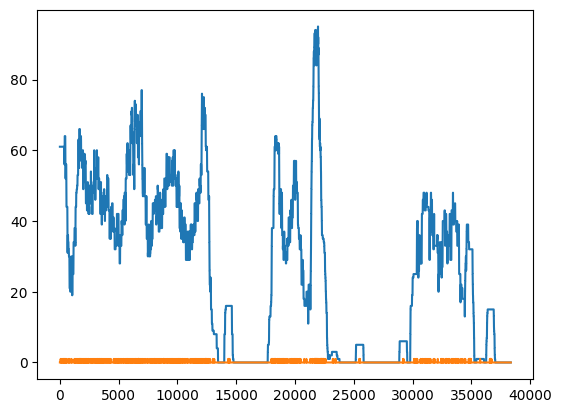

In [129]:
plt.plot(lick_freq)
plt.plot(licks)

In [134]:
correct = get_var_traces_from_X(X, use_indices, 'hits')
num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
reward_freq = correct.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')

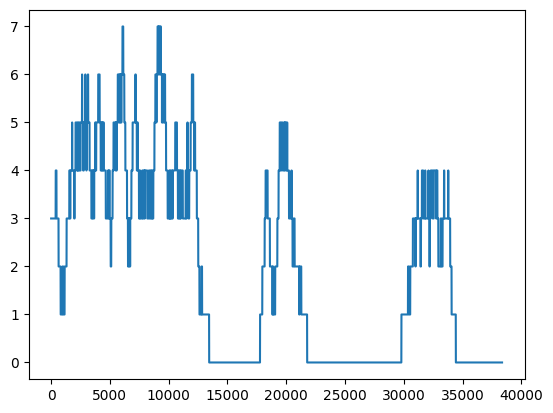

In [135]:
plt.plot(reward_freq)

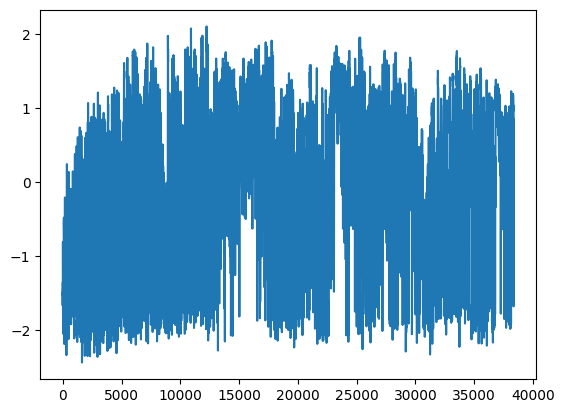

In [138]:
keyword = 'running'
running_speed = get_var_traces_from_X(X, use_indices, keyword)
plt.plot(running_speed)